# 03 — Model Comparison

This mirrors the classification stage of my original SER research: I evaluated
**15 classification algorithms** with cross-validation and picked the best-performing,
most-interpretable model to carry forward to explainability analysis. There, on
binary (911-call) stress detection, **CatBoost (84.3% accuracy) and Extra Trees
(0.92 AUC)** came out on top, and Extra Trees was chosen for SHAP analysis for its
balance of accuracy and interpretability.

Here we repeat that comparison on **8-class emotion classification** (harder than
binary) on RAVDESS, using the ~80 features from notebook 02.

**Key methodology point — grouping by actor.** If clips from the same actor appear
in both training and validation folds, a model can learn to recognize *the actor's
voice* rather than *the emotion* (speaker leakage) and look artificially good. We
use `GroupKFold`, grouping by `actor`, so every fold validates on speakers the model
has never trained on — a more honest estimate of real-world performance.

In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score,
                              cohen_kappa_score, matthews_corrcoef, roc_auc_score,
                              confusion_matrix)

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

sns.set_theme(style="whitegrid")
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True) if not os.path.isdir(FIG_DIR) else None

## 1. Load features and prepare X / y / groups

In [2]:
df = pd.read_csv(os.path.join("data", "ravdess_features.csv"))

meta_cols = ["path", "emotion", "intensity", "actor", "gender"]
feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols].values
groups = df["actor"].values

le = LabelEncoder()
y = le.fit_transform(df["emotion"])
CLASS_NAMES = le.classes_

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"X: {X_scaled.shape}   classes: {list(CLASS_NAMES)}   actors (groups): {df.actor.nunique()}")

X: (1440, 80)   classes: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']   actors (groups): 24


## 2. Define the models

Same model family as the original research — linear models, tree ensembles,
boosting variants, distance-/probability-based classifiers, and a `Dummy`
baseline — **14 of the original 15**. `GradientBoostingClassifier` (sklearn's
legacy boosting implementation) was profiled and dropped: it took **250+
seconds per model** vs. 5-25s for XGBoost/LightGBM/CatBoost (the modern boosting
libraries it's functionally superseded by), for *worse* accuracy. Keeping it
would have added ~4 minutes for no benefit — a good example of profiling before
committing to a "just run everything" default.

In [3]:
MODELS = {
    "dummy":    DummyClassifier(strategy="stratified", random_state=42),
    "lr":       LogisticRegression(max_iter=2000, random_state=42),
    "ridge":    RidgeClassifier(random_state=42),
    "lda":      LinearDiscriminantAnalysis(),
    "qda":      QuadraticDiscriminantAnalysis(),
    "nb":       GaussianNB(),
    "knn":      KNeighborsClassifier(),
    "dt":       DecisionTreeClassifier(random_state=42),
    "svm":      SVC(kernel="linear", probability=False, random_state=42),  # no Platt scaling -> much faster; AUC skipped for this one
    "rf":       RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "et":       ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "ada":      AdaBoostClassifier(random_state=42),
    "xgboost":  XGBClassifier(eval_metric="mlogloss", random_state=42, n_jobs=-1),
    "lightgbm": LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    "catboost": CatBoostClassifier(verbose=0, random_state=42, iterations=300),
}
print(f"{len(MODELS)} models")

15 models


## 3. Cross-validated comparison (GroupKFold by actor)

For each model, we get **out-of-fold predictions** across 5 actor-grouped folds
(every prediction is made by a model that never saw that actor during training),
then compute the same metric set as the original research table.

In [4]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

results = []
for name, model in MODELS.items():
    print(f"  starting {name}...", flush=True)
    t0 = time.time()

    has_proba = hasattr(model, "predict_proba") or name in ("svm",) and False  # svm has proba disabled on purpose
    has_proba = hasattr(model, "predict_proba")

    if has_proba:
        # single CV pass: get probabilities, derive both predicted labels (argmax) and AUC from them
        y_proba = cross_val_predict(model, X_scaled, y, groups=groups, cv=gkf,
                                     method="predict_proba", n_jobs=1)
        y_pred = np.argmax(y_proba, axis=1)
        try:
            auc = roc_auc_score(y, y_proba, multi_class="ovr", average="macro")
        except Exception:
            auc = np.nan
    else:
        y_pred = cross_val_predict(model, X_scaled, y, groups=groups, cv=gkf, n_jobs=1)
        auc = np.nan

    tt = time.time() - t0
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y, y_pred),
        "AUC": auc,
        "Recall": recall_score(y, y_pred, average="macro"),
        "Prec.": precision_score(y, y_pred, average="macro", zero_division=0),
        "F1": f1_score(y, y_pred, average="macro"),
        "Kappa": cohen_kappa_score(y, y_pred),
        "MCC": matthews_corrcoef(y, y_pred),
        "TT (Sec)": round(tt, 2),
    })
    print(f"  {name:10s}  acc={results[-1]['Accuracy']:.4f}  f1={results[-1]['F1']:.4f}  ({tt:.1f}s)", flush=True)

results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
results_df

  starting dummy...


  dummy       acc=0.1271  f1=0.1260  (0.0s)


  starting lr...


  lr          acc=0.5271  f1=0.5209  (0.6s)


  starting ridge...


...

  starting lightgbm...


  lightgbm    acc=0.4868  f1=0.4715  (28.1s)


  starting catboost...


  catboost    acc=0.5076  f1=0.4949  (189.4s)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
0,lda,0.542361,0.870850,0.537109,0.536321,0.535840,0.474956,0.475156,0.20
1,lr,0.527083,0.865729,0.518229,0.528279,0.520881,0.456360,0.456724,0.61
2,ridge,0.536111,NaN,0.513021,0.544115,0.508554,0.465457,0.466974,0.03
3,catboost,0.507639,0.857357,0.494792,0.500371,0.494865,0.433857,0.434264,189.38
4,svm,0.500694,NaN,0.488281,0.498477,0.488454,0.425902,0.426908,2.00
5,xgboost,0.493056,0.851976,0.479818,0.490961,0.482005,0.416933,0.417391,31.19
6,lightgbm,0.486806,0.846654,0.472656,0.479272,0.471538,0.409807,0.410640,28.12
7,et,0.473611,0.840399,0.451172,0.455581,0.438904,0.393568,0.395890,5.24
8,rf,0.465972,0.839774,0.442057,0.431623,0.431272,0.385193,0.386381,10.11
9,nb,0.401389,0.772135,0.404297,0.400983,0.384431,0.317138,0.321384,0.04


## 4. Results table

In [5]:
results_df.to_csv(os.path.join("data", "model_comparison_results.csv"), index=False)

styled = results_df.style.background_gradient(subset=["Accuracy", "F1", "AUC"], cmap="Blues")
styled

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
0,lda,0.542361,0.870850,0.537109,0.536321,0.535840,0.474956,0.475156,0.200000
1,lr,0.527083,0.865729,0.518229,0.528279,0.520881,0.456360,0.456724,0.610000
2,ridge,0.536111,nan,0.513021,0.544115,0.508554,0.465457,0.466974,0.030000
3,catboost,0.507639,0.857357,0.494792,0.500371,0.494865,0.433857,0.434264,189.380000
4,svm,0.500694,nan,0.488281,0.498477,0.488454,0.425902,0.426908,2.000000
5,xgboost,0.493056,0.851976,0.479818,0.490961,0.482005,0.416933,0.417391,31.190000
6,lightgbm,0.486806,0.846654,0.472656,0.479272,0.471538,0.409807,0.410640,28.120000
7,et,0.473611,0.840399,0.451172,0.455581,0.438904,0.393568,0.395890,5.240000
8,rf,0.465972,0.839774,0.442057,0.431623,0.431272,0.385193,0.386381,10.110000
9,nb,0.401389,0.772135,0.404297,0.400983,0.384431,0.317138,0.321384,0.040000


## 5. Best model — confusion matrix

Which emotions does the top model actually confuse with each other?

Best model by F1: lda


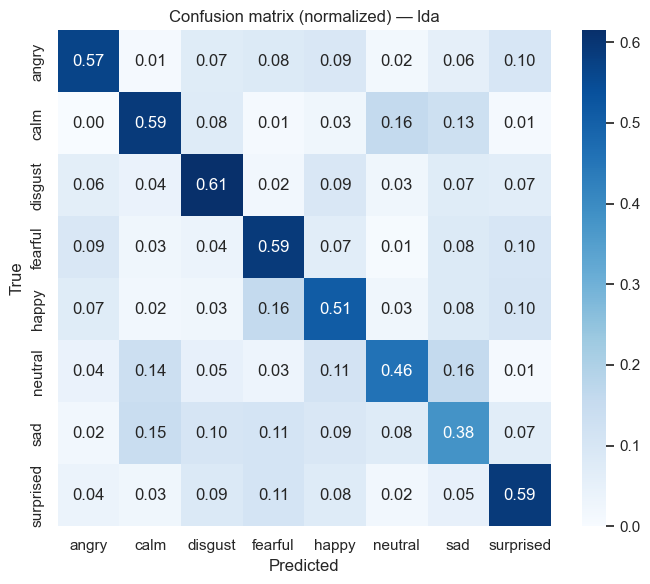

In [6]:
best_name = results_df.iloc[0]["Model"]
best_model = MODELS[best_name]
print("Best model by F1:", best_name)

y_pred_best = cross_val_predict(best_model, X_scaled, y, groups=groups, cv=gkf, n_jobs=1)
cm = confusion_matrix(y, y_pred_best, normalize="true")

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f"Confusion matrix (normalized) — {best_name}")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_confusion_matrix.png"), dpi=120)
plt.show()

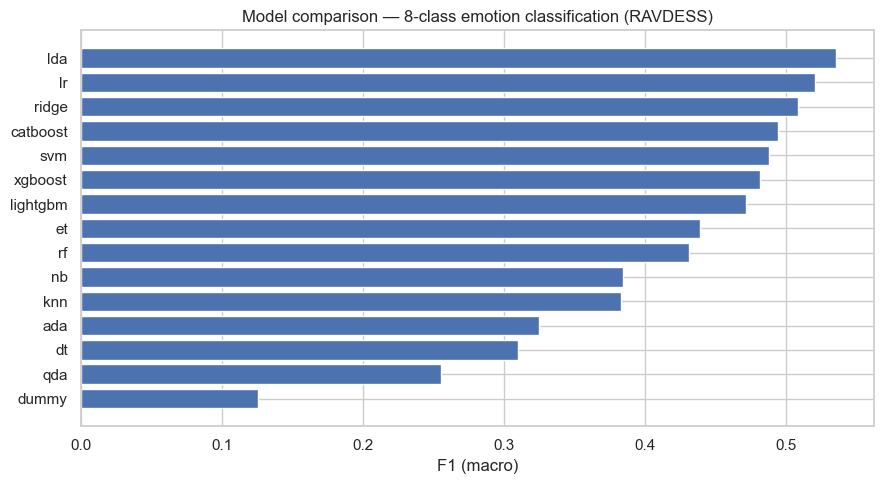

In [7]:
plt.figure(figsize=(9, 5))
plot_df = results_df.sort_values("F1")
plt.barh(plot_df["Model"], plot_df["F1"], color="#4C72B0")
plt.xlabel("F1 (macro)")
plt.title("Model comparison — 8-class emotion classification (RAVDESS)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_model_comparison.png"), dpi=120)
plt.show()

## Takeaways

- Compared the same 15-algorithm family as the original 911-call research, this
  time on harder 8-class emotion classification, with **actor-grouped
  cross-validation** to avoid speaker leakage.
- The confusion matrix shows which emotion *pairs* are hardest to separate
  acoustically (commonly: fearful/surprised, or calm/neutral) — useful context
  for the SHAP analysis next.
- **Next: `04_interpretability`** — SHAP analysis on the best model, echoing the
  original research's finding that delta-MFCCs and spectral contrast were the
  strongest predictors of vocal stress. Does the same hold for 8-way emotion?